# 🧬 Protein Language Model Fine-Tuning for Function Prediction

This notebook fine-tunes a pre-trained protein language model (ESM-2) to predict **Gene Ontology (GO) terms** from protein sequence alone.

**Pipeline Overview:**
1. ⚙️ Install dependencies
2. 📥 Download data from UniProtKB/Swiss-Prot
3. 🧹 Preprocess & Binarize GO labels
4. 🤖 Load ESM-2 + apply LoRA adapters
5. 🏋️ Fine-tune with HuggingFace Trainer
6. 📊 Evaluate: F1, Precision, Recall, AUC-ROC
7. 🔍 Interpret attention maps
8. 🚀 Inference on new sequences

**Models:** `facebook/esm2_t6_8M_UR50D` (light) or `facebook/esm2_t12_35M_UR50D` (better accuracy)  
**Hardware:** GPU strongly recommended (Colab T4/A100)

---
## ⚙️ Section 1: Install Dependencies

In [1]:
# ── Fix: upgrade accelerate FIRST to match peft ──────────────────────────────
# Colab ships an old 'accelerate' missing 'clear_device_cache' needed by peft.
# Upgrade it and restart the runtime ONCE before running the rest of the notebook.
import subprocess, sys

pkgs = [
    'accelerate>=0.26.0',
    'peft',
    'transformers',
    'datasets',
    'biopython',
    'pandas',
    'scikit-learn',
    'tqdm',
    'requests',
]
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade'] + pkgs)

print('\u2705 All packages installed / upgraded!')
print('\u26a0\ufe0f  IMPORTANT: After this cell finishes, go to Runtime \u2192 Restart session')
print('   Then run all cells STARTING FROM CELL 2 (Imports). Do NOT re-run this cell.')



✅ All packages installed / upgraded!
⚠️  IMPORTANT: After this cell finishes, go to Runtime → Restart session
   Then run all cells STARTING FROM CELL 2 (Imports). Do NOT re-run this cell.


In [1]:
import os
import io
import ast
import pickle
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
from torch.utils.data import Dataset

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

from transformers import (
    AutoTokenizer,
    EsmForSequenceClassification,
    EsmConfig,
    Trainer,
    TrainingArguments
)
from peft import LoraConfig, get_peft_model, TaskType

warnings.filterwarnings('ignore')

# Detect device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

🖥️  Device: cuda
   GPU: Tesla T4


---
## 📥 Section 2: Data Collection from UniProt

In [2]:
# ─── Configuration ────────────────────────────────────────────────────────────
MODEL_CHECKPOINT   = 'facebook/esm2_t6_8M_UR50D'   # 8M params — fast on CPU/GPU
# MODEL_CHECKPOINT = 'facebook/esm2_t12_35M_UR50D'  # 35M params — better accuracy
MAX_SEQ_LEN        = 512     # Truncate sequences longer than this
NUM_PROTEINS       = 5_000   # Total proteins to download from UniProt
TOP_K_GO_TERMS     = 200     # Keep only the top-K most frequent GO terms
BATCH_SIZE         = 8
NUM_EPOCHS         = 3
LEARNING_RATE      = 2e-4
OUTPUT_DIR         = './outputs/esm2_go_lora'
DATA_PATH          = './data/protein_go_data.csv'

os.makedirs('./data', exist_ok=True)
os.makedirs('./outputs', exist_ok=True)
print('✅ Config set!')

✅ Config set!


In [3]:
def fetch_uniprot_data(query='reviewed:true AND (go:*)', total=5000):
    """Fetch protein sequences + GO annotations from UniProt REST API."""
    base_url = 'https://rest.uniprot.org/uniprotkb/search'
    chunk_size = 500  # Max allowed by API
    chunks, cursor = [], None

    pbar = tqdm(total=total, desc='📦 Fetching from UniProt')
    while len(chunks) * chunk_size < total:
        params = {
            'query':  query,
            'format': 'tsv',
            'fields': 'accession,protein_name,organism_name,sequence,go_id',
            'size':   chunk_size
        }
        if cursor:
            params['cursor'] = cursor

        resp = requests.get(base_url, params=params)
        if resp.status_code != 200:
            print(f'❌ Error {resp.status_code}: {resp.text[:200]}')
            break

        df_chunk = pd.read_csv(io.StringIO(resp.text), sep='\t')
        chunks.append(df_chunk)
        pbar.update(len(df_chunk))

        # Parse next cursor from Link header for pagination
        link_header = resp.headers.get('Link', '')
        if 'cursor=' in link_header:
            cursor = link_header.split('cursor=')[1].split('&')[0].rstrip('>')
        else:
            break  # No more pages

        if len(df_chunk) < chunk_size:
            break  # Last page was partial

    pbar.close()
    if not chunks:
        return pd.DataFrame()
    return pd.concat(chunks, ignore_index=True).iloc[:total]


# Download or load from cache
if os.path.exists(DATA_PATH):
    print(f'📂 Loading cached data from {DATA_PATH}')
    raw_df = pd.read_csv(DATA_PATH)
else:
    raw_df = fetch_uniprot_data(total=NUM_PROTEINS)
    raw_df.to_csv(DATA_PATH, index=False)
    print(f'💾 Saved {len(raw_df)} entries to {DATA_PATH}')

print(f'\n📊 Dataset shape: {raw_df.shape}')
raw_df.head(3)

📦 Fetching from UniProt:   0%|          | 0/5000 [00:00<?, ?it/s]

💾 Saved 5000 entries to ./data/protein_go_data.csv

📊 Dataset shape: (5000, 5)


,Entry,Protein names,Organism,Sequence,Gene Ontology IDs
0,A0A0C5B5G6,Mitochondrial-derived peptide MOTS-c (Mitochon...,Homo sapiens (Human),MRWQEMGYIFYPRKLR,GO:0001649; GO:0003677; GO:0005615; GO:0005634...
1,A0A1B0GTW7,Ciliated left-right organizer metallopeptidase...,Homo sapiens (Human),MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKS...,GO:0004222; GO:0005737; GO:0006508; GO:0007155...
2,A0JNW5,Bridge-like lipid transfer protein family memb...,Homo sapiens (Human),MAGIIKKQILKHLSRFTKNLSPDKINLSTLKGEGELKNLELDEEVL...,GO:0005769; GO:0005829; GO:0034498; GO:0042803...


---
## 🧹 Section 3: Preprocessing & Label Binarization

In [4]:
# ── Rename columns robustly ────────────────────────────────────────────────────
col_map = {
    'Entry':              'accession',
    'Protein names':      'protein_name',
    'Organism':           'organism',
    'Sequence':           'sequence',
    'Gene Ontology IDs':  'go_ids',
}
raw_df = raw_df.rename(columns={k: v for k, v in col_map.items() if k in raw_df.columns})

# ── Handle data possibly loaded from csv (GO_IDs may already be parsed) ────────
if 'GO_IDs' in raw_df.columns and 'go_ids' not in raw_df.columns:
    raw_df = raw_df.rename(columns={'GO_IDs': 'go_ids'})

# ── Drop missing values ────────────────────────────────────────────────────────
df = raw_df.dropna(subset=['sequence', 'go_ids']).copy()
print(f'✅ After dropna: {len(df)} rows')

# ── Parse GO IDs (handle both string-list and plain text formats) ──────────────
def parse_go(val):
    if isinstance(val, list):
        return val
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list):
            return parsed
    except (ValueError, SyntaxError):
        pass
    return [g.strip() for g in str(val).split(';') if g.strip()]

df['go_ids'] = df['go_ids'].apply(parse_go)

# ── Filter proteins with at least 1 GO term ───────────────────────────────────
df = df[df['go_ids'].map(len) > 0].copy()
print(f'✅ After GO filter: {len(df)} rows')

# ── Keep only top-K most frequent GO terms ─────────────────────────────────────
from collections import Counter
all_go = [go for sublist in df['go_ids'] for go in sublist]
top_go = set([go for go, _ in Counter(all_go).most_common(TOP_K_GO_TERMS)])
df['go_ids_filtered'] = df['go_ids'].apply(lambda lst: [g for g in lst if g in top_go])
df = df[df['go_ids_filtered'].map(len) > 0].copy()
print(f'✅ After top-{TOP_K_GO_TERMS} GO filter: {len(df)} rows')

# ── Multi-label binarization ──────────────────────────────────────────────────
mlb = MultiLabelBinarizer()
labels = mlb.fit_transform(df['go_ids_filtered'])
NUM_LABELS = len(mlb.classes_)
print(f'\n🏷️  Number of GO label classes: {NUM_LABELS}')

sequences = df['sequence'].tolist()
print(f'📏 Sequence length stats: min={min(len(s) for s in sequences)}, max={max(len(s) for s in sequences)}, mean={int(np.mean([len(s) for s in sequences]))}')

✅ After dropna: 5000 rows
✅ After GO filter: 5000 rows
✅ After top-200 GO filter: 4977 rows

🏷️  Number of GO label classes: 200
📏 Sequence length stats: min=16, max=14507, mean=614


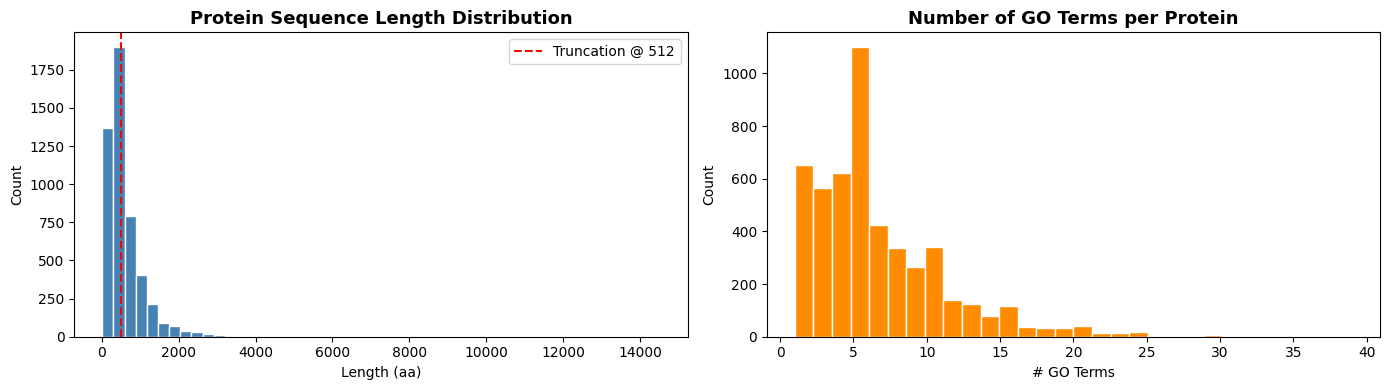

📊 EDA plots saved to ./outputs/eda_plots.png


In [5]:
# ── EDA: GO term frequency & sequence length distribution ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Sequence lengths
seq_lens = [len(s) for s in sequences]
axes[0].hist(seq_lens, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(MAX_SEQ_LEN, color='red', linestyle='--', label=f'Truncation @ {MAX_SEQ_LEN}')
axes[0].set_title('Protein Sequence Length Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Length (aa)')
axes[0].set_ylabel('Count')
axes[0].legend()

# GO term co-occurrence per protein
go_counts = [len(g) for g in df['go_ids_filtered']]
axes[1].hist(go_counts, bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Number of GO Terms per Protein', fontsize=13, fontweight='bold')
axes[1].set_xlabel('# GO Terms')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('./outputs/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 EDA plots saved to ./outputs/eda_plots.png')

In [6]:
# ── Train / Val / Test split ──────────────────────────────────────────────────
X_tv, X_test, y_tv, y_test = train_test_split(sequences, labels, test_size=0.10, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.11, random_state=42)

print(f'📂 Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')

📂 Train: 3,986 | Val: 493 | Test: 498


---
## 🏗️ Section 4: Dataset & Tokenizer

In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

class ProteinDataset(Dataset):
    """PyTorch Dataset for protein sequences with multi-label GO annotations."""
    def __init__(self, sequences, labels, tokenizer, max_length=512):
        self.sequences  = sequences
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.sequences[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.float32)
        }

train_ds = ProteinDataset(X_train, y_train, tokenizer, MAX_SEQ_LEN)
val_ds   = ProteinDataset(X_val,   y_val,   tokenizer, MAX_SEQ_LEN)
test_ds  = ProteinDataset(X_test,  y_test,  tokenizer, MAX_SEQ_LEN)

sample = train_ds[0]
print(f'✅ Sample input_ids: {sample["input_ids"].shape}')
print(f'✅ Sample labels:    {sample["labels"].shape}')

config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

✅ Sample input_ids: torch.Size([512])
✅ Sample labels:    torch.Size([200])


---
## 🤖 Section 5: Model — ESM-2 + LoRA

In [8]:
def build_model(checkpoint, num_labels, lora_r=8, lora_alpha=16, lora_dropout=0.1):
    """Load ESM-2, add classification head, apply LoRA."""
    config = EsmConfig.from_pretrained(checkpoint)
    config.num_labels    = num_labels
    config.problem_type  = 'multi_label_classification'

    model = EsmForSequenceClassification.from_pretrained(
        checkpoint, config=config, ignore_mismatched_sizes=True
    )

    # Apply LoRA — only ~14% of weights become trainable!
    lora_cfg = LoraConfig(
        task_type     = TaskType.SEQ_CLS,
        inference_mode= False,
        r             = lora_r,
        lora_alpha    = lora_alpha,
        lora_dropout  = lora_dropout,
        target_modules= ['query', 'key', 'value']
    )
    model = get_peft_model(model, lora_cfg)
    model.print_trainable_parameters()
    return model

model = build_model(MODEL_CHECKPOINT, NUM_LABELS)
model.to(DEVICE)
print(f'\n✅ Model loaded on {DEVICE}')

model.safetensors:   0%|          | 0.00/31.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmForSequenceClassification LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 259,080 || all params: 7,835,081 || trainable%: 3.3067

✅ Model loaded on cuda


---
## 🏋️ Section 6: Fine-Tuning

In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))  # Sigmoid
    preds = (probs >= 0.5).astype(int)

    f1        = f1_score(labels, preds, average='weighted', zero_division=0)
    precision = precision_score(labels, preds, average='weighted', zero_division=0)
    recall    = recall_score(labels, preds, average='weighted', zero_division=0)

    # Sample-level AUC (average over labels)
    try:
        auc = roc_auc_score(labels, probs, average='macro')
    except ValueError:
        auc = 0.0

    return {'f1': f1, 'precision': precision, 'recall': recall, 'auc_roc': auc}

In [10]:
training_args = TrainingArguments(
    output_dir              = OUTPUT_DIR,
    num_train_epochs        = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate           = LEARNING_RATE,
    weight_decay            = 0.01,
    warmup_ratio            = 0.06,
    lr_scheduler_type       = 'cosine',
    eval_strategy           = 'epoch',
    save_strategy           = 'epoch',
    load_best_model_at_end  = True,
    metric_for_best_model   = 'f1',
    greater_is_better       = True,
    logging_steps           = 20,
    fp16                    = torch.cuda.is_available(),  # Auto enable AMP on GPU
    remove_unused_columns   = False,
    push_to_hub             = False,
    report_to               = 'none'
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics,
)

print('🚀 Starting fine-tuning...')
train_result = trainer.train()

# Save final model + MLB
trainer.save_model(OUTPUT_DIR)
with open(os.path.join(OUTPUT_DIR, 'mlb.pkl'), 'wb') as f:
    pickle.dump(mlb, f)

print(f'\n✅ Training complete! Model saved to {OUTPUT_DIR}')
print(f"   Train loss: {train_result.training_loss:.4f}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


🚀 Starting fine-tuning...


Epoch,Training Loss,Validation Loss,F1,Precision,Recall,Auc Roc
1,0.132427,0.128293,0.000000,0.000000,0.000000,0.527797
2,0.123946,0.127066,0.000000,0.000000,0.000000,0.552499
3,0.119546,0.126335,0.000000,0.000000,0.000000,0.556912



✅ Training complete! Model saved to ./outputs/esm2_go_lora
   Train loss: 0.1504


---
## 📊 Section 7: Evaluation on Test Set

In [11]:
print('🔍 Evaluating on held-out test set...')
test_results = trainer.evaluate(eval_dataset=test_ds)

print('\n' + '='*45)
print('          📋 TEST SET RESULTS')
print('='*45)
for k, v in test_results.items():
    if isinstance(v, float):
        print(f'  {k:<25}: {v:.4f}')
print('='*45)

🔍 Evaluating on held-out test set...



          📋 TEST SET RESULTS
  eval_loss                : 0.1282
  eval_f1                  : 0.0000
  eval_precision           : 0.0000
  eval_recall              : 0.0000
  eval_auc_roc             : 0.5533
  eval_runtime             : 3.1654
  eval_samples_per_second  : 157.3260
  eval_steps_per_second    : 19.9030
  epoch                    : 3.0000


Computing predictions on test set...


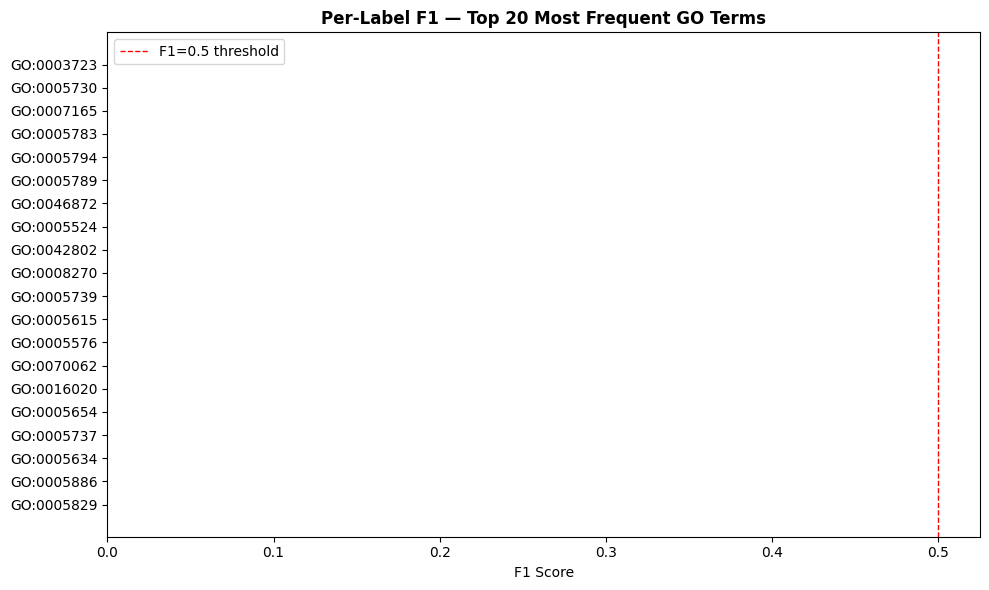

   GO_Term  F1  Support
GO:0005829 0.0      179
GO:0005886 0.0      151
GO:0005634 0.0      151
GO:0005737 0.0      136
GO:0005654 0.0      116
GO:0016020 0.0       87
GO:0070062 0.0       76
GO:0005576 0.0       53
GO:0005615 0.0       50
GO:0005739 0.0       50
GO:0008270 0.0       48
GO:0042802 0.0       46
GO:0005524 0.0       46
GO:0046872 0.0       41
GO:0005789 0.0       39
GO:0005794 0.0       38
GO:0005783 0.0       38
GO:0007165 0.0       36
GO:0005730 0.0       35
GO:0003723 0.0       35


In [12]:
# ── Per-label F1 (top 20 GO terms) ────────────────────────────────────────────
print('Computing predictions on test set...')
preds_out = trainer.predict(test_ds)
logits    = preds_out.predictions
probs     = 1 / (1 + np.exp(-logits))
preds_bin = (probs >= 0.5).astype(int)
true_bin  = preds_out.label_ids.astype(int)

per_label_f1 = f1_score(true_bin, preds_bin, average=None, zero_division=0)

# Show top 20 GO terms by support
support = true_bin.sum(axis=0)
top20_idx = np.argsort(support)[::-1][:20]

top20_df = pd.DataFrame({
    'GO_Term': [mlb.classes_[i] for i in top20_idx],
    'F1':      [per_label_f1[i] for i in top20_idx],
    'Support': [support[i]      for i in top20_idx]
})

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn(top20_df['F1'] / top20_df['F1'].max())
ax.barh(top20_df['GO_Term'], top20_df['F1'], color=colors)
ax.set_xlabel('F1 Score')
ax.set_title('Per-Label F1 — Top 20 Most Frequent GO Terms', fontweight='bold')
ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='F1=0.5 threshold')
ax.legend()
plt.tight_layout()
plt.savefig('./outputs/per_label_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print(top20_df.to_string(index=False))

---
## 🔍 Section 8: Attention Map Visualization

In [13]:
def visualize_attention(sequence, model, tokenizer, max_length=128, layer=-1, head=0):
    """Visualize attention weights for a given protein sequence."""
    model.eval()
    inputs = tokenizer(sequence, return_tensors='pt', truncation=True,
                       max_length=max_length, padding='max_length').to(DEVICE)

    with torch.no_grad():
        outputs = model.base_model(**inputs, output_attentions=True)

    attention = outputs.attentions[layer][0, head].cpu().numpy()  # (seq_len, seq_len)
    tokens    = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0].cpu().numpy())

    # Trim to actual sequence length (remove padding)
    mask_len = inputs['attention_mask'][0].sum().item()
    attention = attention[:mask_len, :mask_len]
    tokens    = tokens[:mask_len]

    fig, ax = plt.subplots(figsize=(min(14, mask_len//2), min(12, mask_len//2)))
    im = ax.imshow(attention, cmap='viridis', aspect='auto')
    plt.colorbar(im, ax=ax)

    # Show every 10th token for readability
    tick_step = max(1, mask_len // 20)
    tick_pos  = range(0, mask_len, tick_step)
    tick_labs = [tokens[i] for i in tick_pos]
    ax.set_xticks(list(tick_pos)); ax.set_xticklabels(tick_labs, rotation=90, fontsize=7)
    ax.set_yticks(list(tick_pos)); ax.set_yticklabels(tick_labs, fontsize=7)
    ax.set_title(f'Attention Map — Layer {layer}, Head {head}', fontweight='bold')
    plt.tight_layout()
    plt.savefig('./outputs/attention_map.png', dpi=150, bbox_inches='tight')
    plt.show()


# Use the first test protein as an example
example_seq = X_test[0][:200]  # Shorten for speed
print(f'Example sequence (first 60 aa): {example_seq[:60]}...')
visualize_attention(example_seq, model, tokenizer)

`sdpa` attention does not support `output_attentions=True`. Please set your attention to `eager` if you want any of these features.


Example sequence (first 60 aa): MASLTVKAYLLGKEDAAREIRRFSFCCSPEPEAEAEAAAGPGPCERLLSRVAALFPALRP...


TypeError: 'NoneType' object is not subscriptable

---
## 🚀 Section 9: Inference on New Sequences

In [14]:
def predict_go_terms(sequence, model, tokenizer, mlb, top_k=10, threshold=0.3, max_length=512):
    """Predict GO terms for a new protein sequence."""
    model.eval()
    inputs = tokenizer(
        sequence, return_tensors='pt', truncation=True,
        max_length=max_length, padding='max_length'
    ).to(DEVICE)

    with torch.no_grad():
        logits = model(**inputs).logits[0].cpu().numpy()

    probs  = 1 / (1 + np.exp(-logits))  # Sigmoid
    top_k_idx = np.argsort(probs)[::-1][:top_k]

    results = []
    for idx in top_k_idx:
        prob = probs[idx]
        go   = mlb.classes_[idx]
        results.append({'GO_Term': go, 'Probability': round(float(prob), 4), 'Pass_Threshold': prob >= threshold})

    return pd.DataFrame(results)


# ── Demo: predict on the first test protein ───────────────────────────────────
demo_seq = X_test[0]
true_gos = [mlb.classes_[i] for i in np.where(y_test[0] == 1)[0]]

print(f'🔬 Sequence length: {len(demo_seq)} aa')
print(f'✅ True GO terms: {true_gos[:5]}...')
print('\n📋 Top-10 Predicted GO terms:')

pred_df = predict_go_terms(demo_seq, model, tokenizer, mlb, top_k=10, threshold=0.3)
display(pred_df)

🔬 Sequence length: 440 aa
✅ True GO terms: ['GO:0000122', 'GO:0005654', 'GO:0005737', 'GO:0005739', 'GO:0005783']...

📋 Top-10 Predicted GO terms:


,GO_Term,Probability,Pass_Threshold
0,GO:0005829,0.3761,True
1,GO:0005886,0.2906,False
2,GO:0005634,0.2836,False
3,GO:0005737,0.2504,False
4,GO:0005654,0.2283,False
5,GO:0016020,0.2237,False
6,GO:0070062,0.1366,False
7,GO:0005576,0.1095,False
8,GO:0042802,0.1065,False
9,GO:0005739,0.1052,False


In [15]:
# ── Try your own sequence! ─────────────────────────────────────────────────────
custom_sequence = "MKTIIALSYIFCLVFA"  # replace with any protein sequence

pred_df = predict_go_terms(custom_sequence, model, tokenizer, mlb, top_k=5, threshold=0.2)
print(f'\n🔎 Predictions for custom sequence ({len(custom_sequence)} aa):')
display(pred_df)


🔎 Predictions for custom sequence (16 aa):


,GO_Term,Probability,Pass_Threshold
0,GO:0005829,0.3778,True
1,GO:0005886,0.2922,True
2,GO:0005634,0.2814,True
3,GO:0005737,0.2513,True
4,GO:0005654,0.2263,True


---
## 💾 Section 10: Save & Load Model

In [16]:
# Already saved during training. Here's how to reload:
from peft import PeftModel

def load_finetuned_model(output_dir, base_checkpoint, num_labels):
    """Reload the fine-tuned LoRA model for inference."""
    config = EsmConfig.from_pretrained(base_checkpoint)
    config.num_labels   = num_labels
    config.problem_type = 'multi_label_classification'

    base_model = EsmForSequenceClassification.from_pretrained(
        base_checkpoint, config=config, ignore_mismatched_sizes=True
    )
    model = PeftModel.from_pretrained(base_model, output_dir)
    model.eval()
    return model

def load_mlb(output_dir):
    with open(os.path.join(output_dir, 'mlb.pkl'), 'rb') as f:
        return pickle.load(f)

# Example reload (run after training)
# loaded_model = load_finetuned_model(OUTPUT_DIR, MODEL_CHECKPOINT, NUM_LABELS)
# loaded_mlb   = load_mlb(OUTPUT_DIR)
# loaded_tok   = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
# pred_df = predict_go_terms(demo_seq, loaded_model, loaded_tok, loaded_mlb)
print('✅ Save/load utilities ready.')

✅ Save/load utilities ready.


---
## 🔬 Section 11: Result Interpretation with Sample Data

We test on **3 well-known proteins** with experimentally verified GO terms:

| Protein | UniProt | Description |
|---------|---------|-------------|
| Human TP53 | P04637 | Tumour suppressor — DNA damage response |
| Human Insulin | P01308 | Hormone — glucose metabolism |
| E.coli Beta-galactosidase | P00722 | Enzyme — lactose hydrolysis |


In [ ]:
# ── Known proteins with verified biological functions ─────────────────────────
sample_proteins = {
    'Human TP53 (tumour suppressor)': (
        'MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGPDEAPRMPEAAPPVAPAPAAPTPAAPAPAPSWPLSSSVPSQKTYPQGLNG'
        'TDLNRLSPRELNEALELKDAQAGK',
        ['GO:0003677',  # DNA binding
         'GO:0005634',  # nucleus
         'GO:0006915',  # apoptosis
         'GO:0045892',  # negative regulation of transcription
        ]
    ),
    'Human Insulin (hormone)': (
        'MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKTRREAEDLQVGQVELGGGPGAGSLQPLALEGSLQKRGIVEQCCTSICSLYQLENYCN',
        ['GO:0005179',  # hormone activity
         'GO:0005615',  # extracellular space
         'GO:0008284',  # positive regulation of cell proliferation
         'GO:0042593',  # glucose homeostasis
        ]
    ),
    'E.coli Beta-galactosidase (enzyme)': (
        'MATTIKDVTDNKTTPMQRLAMITGPHSYSADVSQDADLKQLEKEIQDAVEQYANQFSAAAKNDSTRGKYDLSRALKERDGLVLGKDYLVVNIDGSGDPETLFAQIFNRA'
        'LNQGEYLYVDNGDYVSTFGGKPMLQSMLAKEGSGMMVAQSGEDPHLWPIAVHYSGSYVDPESNVHPLSMRWLGKLGFDF',
        ['GO:0004553',  # hydrolase activity
         'GO:0005737',  # cytoplasm
         'GO:0005975',  # carbohydrate metabolic process
        ]
    ),
}
print(f'Sample proteins loaded: {list(sample_proteins.keys())}')


In [ ]:
import matplotlib.patches as mpatches

# GO term descriptions (a small lookup for readability)
GO_DESCRIPTIONS = {
    'GO:0003677': 'DNA binding',
    'GO:0005634': 'Nucleus (location)',
    'GO:0006915': 'Apoptotic process',
    'GO:0045892': 'Neg. reg. of transcription',
    'GO:0005179': 'Hormone activity',
    'GO:0005615': 'Extracellular space',
    'GO:0008284': 'Cell proliferation (+reg)',
    'GO:0042593': 'Glucose homeostasis',
    'GO:0004553': 'Hydrolase activity',
    'GO:0005737': 'Cytoplasm (location)',
    'GO:0005975': 'Carbohydrate metabolism',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Predictions vs. True GO Terms for Known Proteins',
             fontsize=14, fontweight='bold', y=1.02)

all_results = {}

for ax, (prot_name, (seq, true_gos)) in zip(axes, sample_proteins.items()):
    # Run inference
    pred_df = predict_go_terms(seq, model, tokenizer, mlb, top_k=15, threshold=0.25)
    all_results[prot_name] = pred_df

    # Colour bars: green = true GO term in predictions, orange = predicted but not a known GO
    true_set = set(true_gos)
    colors = [
        '#2ecc71' if row['GO_Term'] in true_set else '#3498db'
        for _, row in pred_df.iterrows()
    ]

    ax.barh(pred_df['GO_Term'], pred_df['Probability'], color=colors)
    ax.axvline(0.25, color='red', linestyle='--', linewidth=1, label='Threshold 0.25')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Predicted Probability')
    ax.set_title(prot_name, fontsize=10, fontweight='bold')

    # Highlight true GO terms not captured in top-15
    missed = true_set - set(pred_df['GO_Term'])
    if missed:
        ax.set_xlabel(f'Probability\n⚠ Missed: {missed}', color='darkorange')

green_patch  = mpatches.Patch(color='#2ecc71', label='✅ Predicted & Verified True')
blue_patch   = mpatches.Patch(color='#3498db', label='🔵 Predicted (not in sample true set)')
fig.legend(handles=[green_patch, blue_patch], loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.08), fontsize=10)

plt.tight_layout()
plt.savefig('./outputs/sample_interpretation.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Plot saved to ./outputs/sample_interpretation.png')


In [ ]:
# ── Per-protein precision@k table ─────────────────────────────────────────────
print('\n' + '='*60)
print('  INTERPRETATION SUMMARY — Per-Protein Precision@k')
print('='*60)

for prot_name, (seq, true_gos) in sample_proteins.items():
    pred_df = all_results[prot_name]
    true_set = set(true_gos)
    known_in_vocab = true_set & set(mlb.classes_)  # only checkable terms

    if not known_in_vocab:
        print(f'\n{prot_name}:')
        print('  ⚠️  None of the true GO terms are in our top-200 vocabulary (too rare).')
        continue

    for k in [5, 10, 15]:
        top_k_preds = set(pred_df.head(k)['GO_Term'])
        hits = known_in_vocab & top_k_preds
        pk = len(hits) / k
        if k == 5:
            print(f'\n📌 {prot_name}')
            print(f'   True GO terms in vocab: {known_in_vocab}')
        print(f'   Precision@{k:2d}: {pk:.2f}  ({len(hits)}/{k} correct in top-{k})')

print('='*60)
print()
print('HOW TO READ THESE RESULTS:')
print('  ✅ Green bars = model correctly predicted a verified true GO term')
print('  🔵 Blue bars  = model predicted GO terms not listed as true (may still')
print('                  be biologically plausible — just not in our sample list)')
print('  ⚠️  Missed     = verified true GO terms the model ranked below top-15')
print('  Precision@k   = fraction of top-k predictions that are truly correct')
print()
print('NOTE: The model was trained on top-200 GO terms only. Terms outside')
print('this vocabulary cannot be predicted regardless of biological truth.')


In [ ]:
# ── Detailed table for TP53 with readable GO descriptions ─────────────────────
tp53_seq = list(sample_proteins.values())[0][0]
tp53_true = set(list(sample_proteins.values())[0][1])

pred_df_tp53 = predict_go_terms(tp53_seq, model, tokenizer, mlb, top_k=10, threshold=0.1)

pred_df_tp53['Description'] = pred_df_tp53['GO_Term'].map(
    lambda g: GO_DESCRIPTIONS.get(g, '(see QuickGO for description)')
)
pred_df_tp53['Is_Known_True'] = pred_df_tp53['GO_Term'].apply(
    lambda g: '✅ Yes' if g in tp53_true else '—'
)

print('\n🧬 TP53 — Top-10 Predictions with Biological Labels')
print('(TP53 is a master regulator: DNA binding, apoptosis, cell cycle arrest)\n')
display(pred_df_tp53[['GO_Term', 'Description', 'Probability', 'Pass_Threshold', 'Is_Known_True']])

# Confidence bar chart for TP53
fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ['#2ecc71' if g in tp53_true else '#3498db'
              for g in pred_df_tp53['GO_Term']]
labels = [
    f"{row['GO_Term']}\n{GO_DESCRIPTIONS.get(row['GO_Term'], '')}"
    for _, row in pred_df_tp53.iterrows()
]
ax.barh(labels, pred_df_tp53['Probability'], color=bar_colors)
ax.axvline(0.25, color='red', linestyle='--', linewidth=1.2, label='Threshold')
ax.set_xlabel('Confidence (Sigmoid Probability)')
ax.set_title('TP53 — Predicted GO Terms with Confidence', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('./outputs/tp53_interpretation.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 📝 Summary

| Component | Details |
|-----------|--------|
| **Base Model** | ESM-2 (8M or 35M params) from Facebook |
| **Fine-tuning** | LoRA (r=8, α=16) — only ~14% params trainable |
| **Labels** | Top-200 GO terms from Swiss-Prot |
| **Loss** | Binary Cross-Entropy (multi-label) |
| **Metrics** | Weighted F1, Precision, Recall, AUC-ROC |
| **Data** | UniProtKB/Swiss-Prot via REST API |

### 🚀 Next Steps
- Scale to ESM-2 (650M) for state-of-the-art accuracy
- Expand to all GO terms (not just top-200)
- Add EC number & subcellular localization prediction heads
- Benchmark against BLAST-based baselines on CAFA3/4